Это обзорный ноутбук, служит для  того, чтобы было легче ознакомиться с данными, что мы имеем

In [61]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_categories = pd.read_csv('D:\ML_innovise\item_categories.csv')
df_categories.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Barys\AppData\Local\Temp\ipykernel_16944\2812265462.py:1: SyntaxWarning: invalid escape sequence '\M'
  df_categories = pd.read_csv('D:\ML_innovise\item_categories.csv')


,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [4]:
df_categories.describe()

,item_category_id
count,84.000000
mean,41.500000
std,24.392622
min,0.000000
25%,20.750000
50%,41.500000
75%,62.250000
max,83.000000


In [5]:
df_categories.nunique()

item_category_name    84
item_category_id      84
dtype: int64

Обзор данного csv-файла: в нем 84 записи, все уникальные, нет случайных ошибок с повторением, просто содержит название категории и ее номер, ничего необычного 
* могу предположить, что в будущем мы сможем это использовать для прогнозивания, отслеживая, что какая-то категория товаров продается плохо, какая-хорошо и это повлияет на прогноз

In [6]:
df_items = pd.read_csv('D:\ML_innovise\items.csv')
df_items.head()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Barys\AppData\Local\Temp\ipykernel_16944\972057133.py:1: SyntaxWarning: invalid escape sequence '\M'
  df_items = pd.read_csv('D:\ML_innovise\items.csv')


,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [7]:
df_items.describe()

,item_id,item_category_id
count,22170.00000,22170.000000
mean,11084.50000,46.290753
std,6400.07207,15.941486
min,0.00000,0.000000
25%,5542.25000,37.000000
50%,11084.50000,40.000000
75%,16626.75000,58.000000
max,22169.00000,83.000000


csv файл, содержит информацию о товаре: id товара и id категории этого товара. Я бы сказала, что нам не сильно важно, что скрывается за id товара и как сам товар называется, его id можно сравнить с label encoding, где в соответсвие товару ставится номер, но что за товар нам в прирнципе не сильно важно. Другое дело, что в этом файле содержится id-категории, который смысловую нагрузку для дальнейшего прогнозирования вполне может нести, я бы вытащила эту информацию в отдельный датафрейм вместе с основной.

In [8]:
df_sales_train = pd.read_csv('D:\ML_innovise\sales_train.csv')
df_sales_train.head()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Barys\AppData\Local\Temp\ipykernel_16944\1671957599.py:1: SyntaxWarning: invalid escape sequence '\M'
  df_sales_train = pd.read_csv('D:\ML_innovise\sales_train.csv')


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [9]:
df_sales_train.describe()

,date_block_num,shop_id,item_id,item_price,item_cnt_day
count,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06
mean,1.456991e+01,3.300173e+01,1.019723e+04,8.908532e+02,1.242641e+00
std,9.422988e+00,1.622697e+01,6.324297e+03,1.729800e+03,2.618834e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-2.200000e+01
25%,7.000000e+00,2.200000e+01,4.476000e+03,2.490000e+02,1.000000e+00
50%,1.400000e+01,3.100000e+01,9.343000e+03,3.990000e+02,1.000000e+00
75%,2.300000e+01,4.700000e+01,1.568400e+04,9.990000e+02,1.000000e+00
max,3.300000e+01,5.900000e+01,2.216900e+04,3.079800e+05,2.169000e+03


In [10]:
df_sales_train['date'].dtype

dtype('O')

Стоит обратить внимание, что тип столбца date - Object, если мы хотим тип в date, придется производить преобразования. Я бы предполоижила. что раз придется сделать прогноз на ноябрь как целый месяц, то нет смысла хранить информацию по каждому дню, гораздо профитнее по каждому месяцу для каждого товара, поэтому в будущем предлагаю сделать группировку. 

На мой взгляд, основной файл, который содержит ключевую информацию, с которой бцдем работать. Здесь информация о дате, номер месяца этой даты, если вести отсчет от января 2013 года (чисто для удобства так понимаю), id магазина, id товара (который продавался в этом миагазине в эту дату), цена товара(не совсем понятно для чего, но я бы в будущем заменила бы этот признак на категориальный, в стиле товар с таком ценовом диапозоне, можно сделать предположение, что дорогие товары например будут мало покупать), сколько продали товара на конкретную дату в определенном магазине.

In [11]:
df_submission = pd.read_csv('D:\ML_innovise\sample_submission.csv')
df_submission.head()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Barys\AppData\Local\Temp\ipykernel_16944\3921238710.py:1: SyntaxWarning: invalid escape sequence '\M'
  df_submission = pd.read_csv('D:\ML_innovise\sample_submission.csv')


,ID,item_cnt_month
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


Просто пример того, какой должен быть результат прогноза: ID - кортеж, который содержит пару (id машазина и id товара), результат нашего прогноза, сколько продадут этого товара в конретном магазине за ноябрь 2015.

In [12]:
df_shops = pd.read_csv('D:\ML_innovise\shops.csv')
df_shops.head()


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Barys\AppData\Local\Temp\ipykernel_16944\3718596122.py:1: SyntaxWarning: invalid escape sequence '\M'
  df_shops = pd.read_csv('D:\ML_innovise\shops.csv')


,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [13]:
df_shops.describe()

,shop_id
count,60.000000
mean,29.500000
std,17.464249
min,0.000000
25%,14.750000
50%,29.500000
75%,44.250000
max,59.000000


In [14]:
df_shops['shop_id'].nunique()

60

csv файл содержит информацию с названием магазина, и id, которое мы поставили в соответствие с названием магазина, всего 60 значений, все уникальные, получается нет пропусков и повторений, значит ошибок нет. Я считаю, можно не сипользовать эту информацию и рассматривать ее исключительно как label-encoding.

In [15]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_testt.head()


,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


В этом csv файле просто содержится информация про то, именно какие нас магазины товары инетересуют, какой кортеж стоит за каждым ID

Итак, на данном этапе мы осмотрели, какие данные мы имеем, дальше я бы действовала таким образом: 
- собрать все данные, которые я считаю полезными для дальнейшего прогнозирования, в одном датафрейме.
- найти выбросы, пропуски, дисбаланс проверить классов, проверить провалы во временном диапозоне (тк работаем со врмеенными рядами), дубликаты, нет ли цен равных нулю- с этим немного пошаманить
- подготовить данные для выдачи на дальнейшие этапы ( сформировать новые признаки, удалить может старые и все такое)

In [16]:
merged_df = df_sales_train.merge(
    df_items,           
    on='item_id',       
    how='left',         
    validate='many_to_one'  
)

merged_df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56


In [17]:
merged_full = merged_df.merge(
    df_categories,            
    on='item_category_id',  
    how='left',             
    validate='many_to_one'  
)

merged_full.head()


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства


In [18]:
merged_all = merged_full.merge(
    df_shops,     
    on='shop_id', 
    how='left',   
    validate='many_to_one'  )
merged_all.tail()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
2935844,10.10.2015,33,25,7409,299.0,1.0,V/A Nu Jazz Selection (digipack),55,Музыка - CD локального производства,"Москва ТРК ""Атриум"""
2935845,09.10.2015,33,25,7460,299.0,1.0,V/A The Golden Jazz Collection 1 2CD,55,Музыка - CD локального производства,"Москва ТРК ""Атриум"""
2935846,14.10.2015,33,25,7459,349.0,1.0,V/A The Best Of The 3 Tenors,55,Музыка - CD локального производства,"Москва ТРК ""Атриум"""
2935847,22.10.2015,33,25,7440,299.0,1.0,V/A Relax Collection Planet MP3 (mp3-CD) (jewel),57,Музыка - MP3,"Москва ТРК ""Атриум"""
2935848,03.10.2015,33,25,7460,299.0,1.0,V/A The Golden Jazz Collection 1 2CD,55,Музыка - CD локального производства,"Москва ТРК ""Атриум"""


In [19]:
merged_all.isna().sum()


date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64

In [42]:
df_test = merged_all.merge(
    df_testt,
    on=['shop_id', 'item_id'],
    how='left',     
    validate='many_to_one'
)
df_test.head()


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",NaN


In [21]:
new_order = [
    'ID', 'item_id', 'shop_id', 'item_price', 'date', 'date_block_num',
    'item_cnt_day', 'item_category_id', 'item_category_name',
    'item_name', 'shop_name'
]
df_test = df_test[new_order]
df_test.head()


,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
0,150983.0,22154,59,999.00,02.01.2013,0,1.0,37,Кино - Blu-Ray,ЯВЛЕНИЕ 2012 (BD),"Ярославль ТЦ ""Альтаир"""
1,NaN,2552,25,899.00,03.01.2013,0,1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP,"Москва ТРК ""Атриум"""
2,NaN,2552,25,899.00,05.01.2013,0,-1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP,"Москва ТРК ""Атриум"""
3,NaN,2554,25,1709.05,06.01.2013,0,1.0,58,Музыка - Винил,DEEP PURPLE Who Do You Think We Are LP,"Москва ТРК ""Атриум"""
4,NaN,2555,25,1099.00,15.01.2013,0,1.0,56,Музыка - CD фирменного производства,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),"Москва ТРК ""Атриум"""


In [22]:
df_test.isna().sum()

ID                    1711410
item_id                     0
shop_id                     0
item_price                  0
date                        0
date_block_num              0
item_cnt_day                0
item_category_id            0
item_category_name          0
item_name                   0
shop_name                   0
dtype: int64

В общем сначала я подумала, вот возьму смерджу через inner join по (shop_id, item_id), короче оставлю только те данные, которые нам в перспективе нужно будет предсказывать, но! я поняла, что тогда мы отбросим очень большую часть данных, которые потенциально нам могут офигеть как пригодиться, например: есть вид наушников, которые нам нужно предсказать в ноябре, а есть очень похожие, но предсказывать их продажу будет не нужно и мы просто выкинем информацию о них, хотя они могут нам очень помочь. Поэтому я опять смерджила через left join, пусть останутся проспуски в ID, просто мы будем знать откуда они и не трогать их.

Теперь предстоит изучим наши данные по следующим критериям:
- полнота
- точность
- согласованность 
- валидность
- уникальность
- целостность
- доступность
- своевременность
- релевантность 

### Полнота:
Мы проверили, что пропуски только в ID и мы знаем почему

### ТОчность:
Тут уже будем проверять, нет ли отрицательных значений, где их быть не должно, экстремально невозможных значений и тд

In [23]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ID                  float64
 1   item_id             int64  
 2   shop_id             int64  
 3   item_price          float64
 4   date                object 
 5   date_block_num      int64  
 6   item_cnt_day        float64
 7   item_category_id    int64  
 8   item_category_name  object 
 9   item_name           object 
 10  shop_name           object 
dtypes: float64(3), int64(4), object(4)
memory usage: 246.4+ MB


In [24]:
df_test.describe()

,ID,item_id,shop_id,item_price,date_block_num,item_cnt_day,item_category_id
count,1.224439e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06
mean,9.517727e+04,1.019723e+04,3.300173e+01,8.908532e+02,1.456991e+01,1.242641e+00,4.000138e+01
std,5.651974e+04,6.324297e+03,1.622697e+01,1.729800e+03,9.422988e+00,2.618834e+00,1.710076e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-2.200000e+01,0.000000e+00
25%,4.784100e+04,4.476000e+03,2.200000e+01,2.490000e+02,7.000000e+00,1.000000e+00,2.800000e+01
50%,8.716000e+04,9.343000e+03,3.100000e+01,3.990000e+02,1.400000e+01,1.000000e+00,4.000000e+01
75%,1.400990e+05,1.568400e+04,4.700000e+01,9.990000e+02,2.300000e+01,1.000000e+00,5.500000e+01
max,2.141990e+05,2.216900e+04,5.900000e+01,3.079800e+05,3.300000e+01,2.169000e+03,8.300000e+01


Какие есть потенциально опасные места:
- отрицательность там, где быть не должно (видим, что такая только в цене товара неуместна)
* цена товара = 0, допустим по уценке
* отриц кол-во продаж  - это возврат 
- целостность item_cnt_day
- выбросы в item_price, item_cnt_day


In [25]:
min_val = df_test['date_block_num'].min()
max_val = df_test['date_block_num'].max()
print(min_val, max_val)


0 33


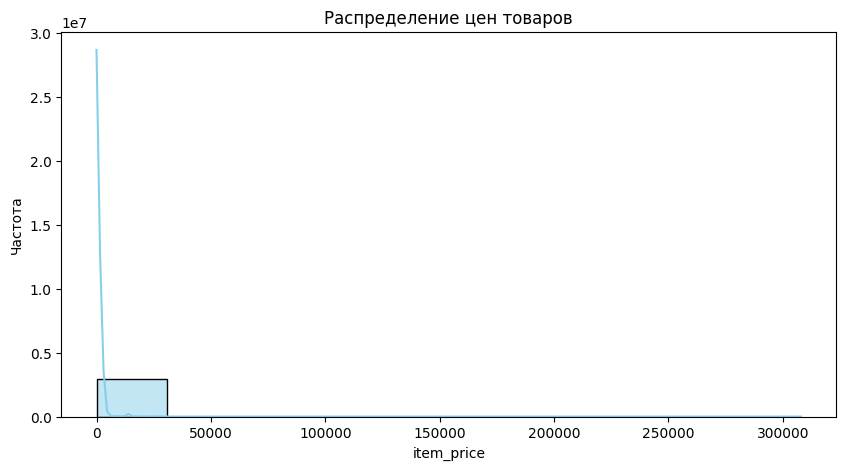

In [43]:
plt.figure(figsize=(10, 5))
sns.histplot(df_test['item_price'], bins=10, kde=True,
             color='skyblue', edgecolor='black')
plt.title('Распределение цен товаров')
plt.xlabel('item_price')
plt.ylabel('Частота')
plt.show()


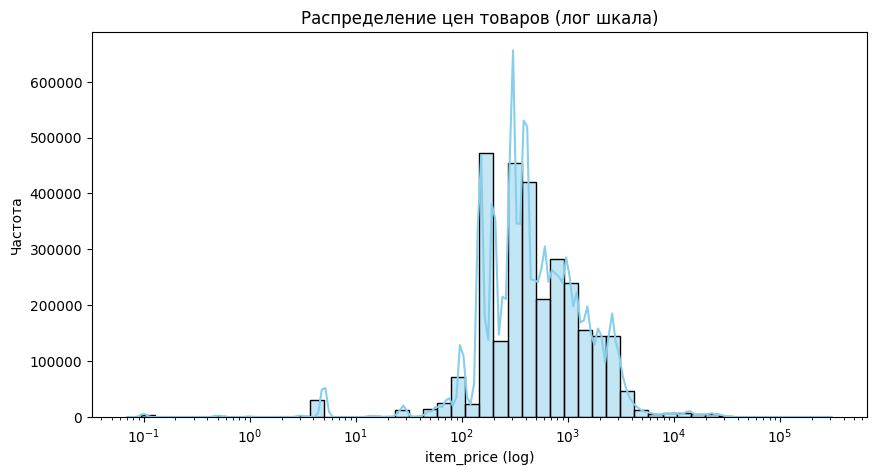

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(df_test['item_price'],
             bins=50,
             kde=True,
             color='skyblue',
             edgecolor='black',
             log_scale=(True, False))  # log scale по нашей оси X
plt.title('Распределение цен товаров (лог шкала)')
plt.xlabel('item_price (log)')
plt.ylabel('Частота')
plt.show()


In [48]:
df_test['date'] = pd.to_datetime(
    df_test['date'],
    format='%d.%m.%Y'      # день.месяц.год
)


In [49]:
df_test['date'].head()

0   2013-01-02
1   2013-01-03
2   2013-01-05
3   2013-01-06
4   2013-01-15
Name: date, dtype: datetime64[ns]

In [50]:
df_test['date'].dtype
# datetime64[ns]


dtype('<M8[ns]')

<Axes: ylabel='item_price'>

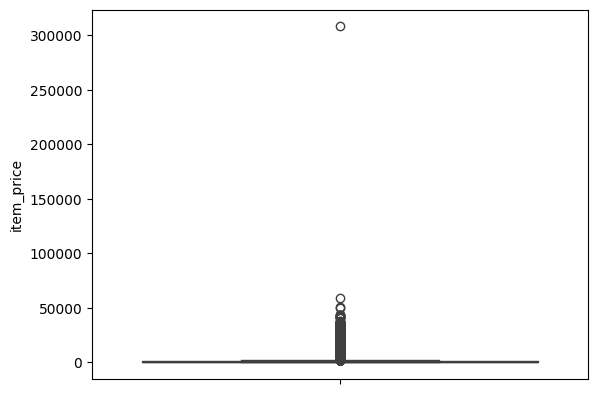

In [27]:
sns.boxplot(df_test['item_price'])


In [28]:
# сначала разберемся. что же за выбросы в цене товара
rich_items = df_test[df_test['item_price'] > 100_000]
(len(rich_items))
rich_items.head(5)


,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
1163158,NaN,6066,12,307980.0,13.12.2013,11,1.0,75,Программы - Для дома и офиса,Radmin 3 - 522 лиц.,Интернет-магазин ЧС


In [29]:
same_items = df_test[df_test['item_category_id'] ==75]
same_items

,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
207,NaN,2220,25,3990.0,11.01.2013,0,1.0,75,Программы - Для дома и офиса,COREL Pinnacle Systems STUDIO Ultimate V.16 П...,"Москва ТРК ""Атриум"""
208,NaN,2221,25,1990.0,07.01.2013,0,1.0,75,Программы - Для дома и офиса,COREL Pinnacle Systems STUDIO V.16 Программно...,"Москва ТРК ""Атриум"""
209,NaN,2412,25,5490.0,02.01.2013,0,1.0,75,Программы - Для дома и офиса,CorelDRAW Home & Student Suite X6 Mini box Rus...,"Москва ТРК ""Атриум"""
278,56653.0,3141,25,1130.0,26.01.2013,0,1.0,75,Программы - Для дома и офиса,ESET NOD32 Smart Security - продление лицензии...,"Москва ТРК ""Атриум"""
279,56653.0,3141,25,1130.0,31.01.2013,0,1.0,75,Программы - Для дома и офиса,ESET NOD32 Smart Security - продление лицензии...,"Москва ТРК ""Атриум"""
...,...,...,...,...,...,...,...,...,...,...,...
2934906,56669.0,3148,25,1850.0,06.10.2015,33,1.0,75,Программы - Для дома и офиса,ESET NOD32 Smart Security+ Bonus + расширенный...,"Москва ТРК ""Атриум"""
2935105,57308.0,8528,25,850.0,20.10.2015,33,1.0,75,Программы - Для дома и офиса,Антивирус ESET NOD32 - продление лицензии на 1...,"Москва ТРК ""Атриум"""
2935660,57306.0,7812,25,5990.0,22.10.2015,33,1.0,75,Программы - Для дома и офиса,Win 8.1 32-bit/64-bit Russian Russia Only DVD,"Москва ТРК ""Атриум"""
2935661,58439.0,7668,25,7990.0,07.10.2015,33,1.0,75,Программы - Для дома и офиса,WIN HOME 10 32-bit/64-bit Russian Russia Only USB,"Москва ТРК ""Атриум"""


In [30]:
df_test['item_price'] = df_test['item_price'].abs()
df_test['item_price'].describe()


count    2.935849e+06
mean     8.908532e+02
std      1.729800e+03
min      7.000000e-02
25%      2.490000e+02
50%      3.990000e+02
75%      9.990000e+02
max      3.079800e+05
Name: item_price, dtype: float64

In [31]:
df_test['item_cnt_day'] = df_test['item_cnt_day'].astype(int)


Text(0.5, 1.0, 'Сумма продаж по месяцам')

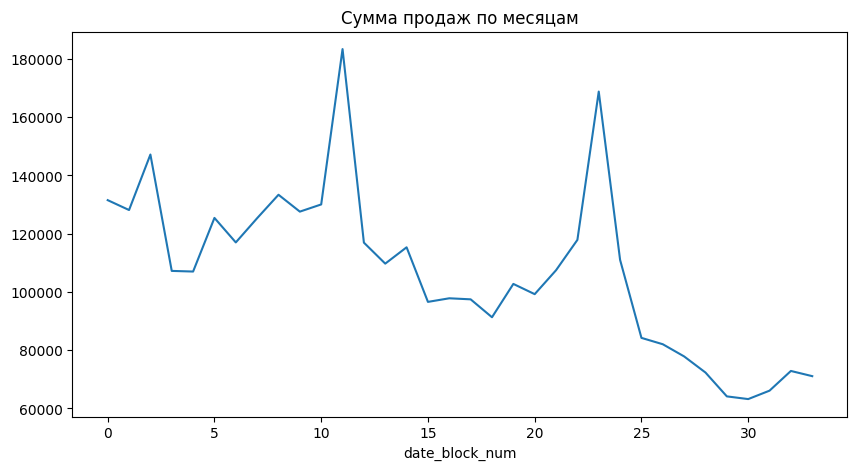

In [32]:
df_test.groupby('date_block_num')['item_cnt_day'].sum().plot(figsize=(10,5))
plt.title('Сумма продаж по месяцам')


По графику видно, что нет разрывов и есть данные о каждом месяце за данный промежуток времени, есть скачки, но они не похожи на аномальные, видна даже нейкая периодичность (сезонность)

<Axes: ylabel='item_cnt_day'>

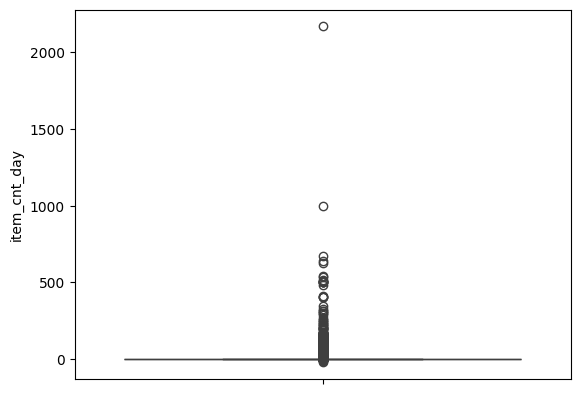

In [33]:
sns.boxplot(df_test['item_cnt_day'])

In [34]:
selected = df_test[df_test['item_cnt_day'] > 900]
selected


,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
2326930,36160.0,20949,12,4.000000,15.01.2015,24,1000,71,"Подарки - Сумки, Альбомы, Коврики д/мыши",Фирменный пакет майка 1С Интерес белый (34*42)...,Интернет-магазин ЧС
2909818,37296.0,11373,12,0.908714,28.10.2015,33,2169,9,Доставка товара,Доставка до пункта выдачи (Boxberry),Интернет-магазин ЧС


In [35]:
delivery = df_test[df_test['item_category_id'] == 9]
delivery

,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
58283,37350.0,11365,12,1148.000000,09.01.2013,0,5,9,Доставка товара,Доставка (EMS),Интернет-магазин ЧС
58284,37350.0,11365,12,2235.000000,10.01.2013,0,2,9,Доставка товара,Доставка (EMS),Интернет-магазин ЧС
58285,37350.0,11365,12,1753.333333,14.01.2013,0,3,9,Доставка товара,Доставка (EMS),Интернет-магазин ЧС
58286,37350.0,11365,12,1435.000000,15.01.2013,0,2,9,Доставка товара,Доставка (EMS),Интернет-магазин ЧС
58287,37350.0,11365,12,1930.000000,16.01.2013,0,1,9,Доставка товара,Доставка (EMS),Интернет-магазин ЧС
...,...,...,...,...,...,...,...,...,...,...,...
2909996,39455.0,13753,12,319.500000,28.10.2015,33,2,9,Доставка товара,Курьерская доставка (Boxberry),Интернет-магазин ЧС
2909997,39455.0,13753,12,269.000000,15.10.2015,33,4,9,Доставка товара,Курьерская доставка (Boxberry),Интернет-магазин ЧС
2909998,39455.0,13753,12,917.000000,13.10.2015,33,1,9,Доставка товара,Курьерская доставка (Boxberry),Интернет-магазин ЧС
2910021,39455.0,13753,12,329.000000,01.10.2015,33,1,9,Доставка товара,Курьерская доставка (Boxberry),Интернет-магазин ЧС


Интересно, что аномальными по количеству продажи являются пакеты и доставка, причем в одном и том же магазине. Чисто логически, это может быть правдой: сколько пакетов покупают люди и сколько оформляют доставку, может это вообще очень популярный магазин. НО сейчас мы это проверим.

In [36]:
df_shop = df_test[df_test['shop_id']==12]
df_shop.head()

,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
58263,NaN,9999,12,149.0,15.01.2013,0,-1,40,Кино - DVD,ВОЛШЕБНАЯ ИСТОРИЯ ЖАСМИН. ПРИНЦЕССЫ (регион),Интернет-магазин ЧС
58264,NaN,10097,12,699.0,17.01.2013,0,1,38,Кино - Blu-Ray 3D,ВСЕЛЕННАЯ. 7 ЧУДЕС СОЛНЕЧНОЙ СИСТЕМЫ (3D BD),Интернет-магазин ЧС
58265,NaN,10163,12,1449.0,15.01.2013,0,1,55,Музыка - CD локального производства,ВЫСОЦКИЙ ВЛАДИМИР Песни о... 6CD (box),Интернет-магазин ЧС
58266,NaN,10323,12,2299.0,10.01.2013,0,1,41,Кино - Коллекционное,ГАРРИ ПОТТЕР (коллекц. 16 DVD),Интернет-магазин ЧС
58267,NaN,10323,12,2299.0,30.01.2013,0,1,41,Кино - Коллекционное,ГАРРИ ПОТТЕР (коллекц. 16 DVD),Интернет-магазин ЧС


In [37]:
df_purchases = df_shop[df_shop['date']=='28.10.2015']
df_only_purchases = df_purchases[df_purchases['item_category_id'] != 9]
df_only_purchases.head()

,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
2909328,37664.0,20629,12,2399.0,28.10.2015,33,1,72,Подарки - Фигурки,"Фигурка Mortal Kombat X Series 1 Scorpion 6""",Интернет-магазин ЧС
2909340,NaN,19971,12,3199.0,28.10.2015,33,1,61,Подарки - Атрибутика,Толстовка Minecraft Enderman Zip-up детская че...,Интернет-магазин ЧС
2909354,38859.0,20195,12,720.0,28.10.2015,33,1,49,Книги - Методические материалы 1С,"Учет налога на прибыль в ""1С:Бухгалтерии 8"". 3...",Интернет-магазин ЧС
2909399,36192.0,20866,12,699.0,28.10.2015,33,1,72,Подарки - Фигурки,Фигурка Tom Clancy's Splinter Cell Blacklist S...,Интернет-магазин ЧС
2909405,NaN,21013,12,1899.0,28.10.2015,33,1,61,Подарки - Атрибутика,Футболка Assassin's Creed Syndicate Rook XL,Интернет-магазин ЧС


In [38]:
df_only_purchases['item_cnt_day'].sum()

np.int64(74)

Что получается: интернет магазин продал за 28.10.2015	всего 74 товара - это максимум 74 доставки в этот день при условии, что каждый пользователь заказал по 1 товару. А доставки было в этот день 2169 - мне кажется, что это подман.

In [39]:
df_purchases = df_shop[df_shop['date']=='15.01.2015']
df_only_purchases = df_purchases[df_purchases['item_id'] != 20949]
df_only_purchases.head()

,ID,item_id,shop_id,item_price,date,date_block_num,item_cnt_day,item_category_id,item_category_name,item_name,shop_name
2326545,38379.0,19507,12,2499.0,15.01.2015,24,1,61,Подарки - Атрибутика,Сундук для хранения Minecraft 30*30*30 см кожз...,Интернет-магазин ЧС
2326547,NaN,19635,12,1699.0,15.01.2015,24,1,41,Кино - Коллекционное,ТЕМНЫЙ РЫЦАРЬ. ТРИЛОГИЯ (5 BD+Артбук),Интернет-магазин ЧС
2326610,NaN,20544,12,1999.0,15.01.2015,24,1,72,Подарки - Фигурки,"Фигурка Halo Master Chief with Cloak 6""",Интернет-магазин ЧС
2326614,NaN,20397,12,1999.0,15.01.2015,24,1,72,Подарки - Фигурки,Фигурка Assassin's Creed Series 3 Altair Ibn-L...,Интернет-магазин ЧС
2326645,36656.0,16790,12,2199.0,15.01.2015,24,1,20,Игры - PS4,"Одни из нас. Обновленная версия [PS4, русская ...",Интернет-магазин ЧС


In [40]:
df_only_purchases['item_cnt_day'].sum()

np.int64(103)

А вот в этот день продали в этом интернет магазине 103 товара, а пакетов 1000, крайне сомнительно.

Мой вывод по выбросам - крайне сомнительно.

In [52]:

last_seen = (
    df_sales_train
    .groupby(['shop_id', 'item_id'], as_index=False)['date_block_num']
    .max()
    .rename(columns={'date_block_num': 'mnth_last_purchase'})
)

df_test = df_test.merge(
    last_seen,
    on=['shop_id', 'item_id'],
    how='left'
)

df_test['mnth_last_purchase'] = df_test['mnth_last_purchase'].fillna(-1).astype(int)
df_test['mnth_last_purchase'].value_counts()

mnth_last_purchase
33    571895
32    216020
31    162812
30    152063
26    128056
24    102526
23     97654
29     97194
27     96810
28     93601
25     92044
19     76290
11     69646
18     67922
21     65038
22     64650
17     64426
14     61139
12     58811
20     57125
13     55691
16     54259
15     51606
8      45917
9      43877
10     43786
7      43180
6      38301
5      33566
1      31016
4      27543
3      26943
2      26915
0      17527
Name: count, dtype: int64

In [53]:
df_test.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID,mnth_last_purchase
0,2013-01-02,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0,0
1,2013-01-03,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0
2,2013-01-05,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0
3,2013-01-06,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0
4,2013-01-15,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",NaN,11


In [59]:
cu = df_test[(df_test['item_id'] == 22154) &(df_test['shop_id'] == 59)]
cu

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID,mnth_last_purchase
0,2013-01-02,0,59,22154,999.0,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0,0


In [60]:
df_test['mnth_cnt_purchase'] = (
    df_test
    .groupby(['shop_id', 'item_id'])['date_block_num']
    .transform('nunique')
)
df_test.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID,mnth_last_purchase,mnth_cnt_purchase
0,2013-01-02,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0,0,1
1,2013-01-03,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1
2,2013-01-05,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1
3,2013-01-06,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1
4,2013-01-15,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",NaN,11,7


In [62]:
df_test['not_old'] = np.where(
    df_test['mnth_last_purchase'] < 25,
    0,
    1
)
df_test.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID,mnth_last_purchase,mnth_cnt_purchase,not_old
0,2013-01-02,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0,0,1,0
1,2013-01-03,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0
2,2013-01-05,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0
3,2013-01-06,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0
4,2013-01-15,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",NaN,11,7,0


In [63]:
df_test['enough_inf'] = np.where(
    df_test['mnth_cnt_purchase'] < 9,
    0,
    1
)
df_test.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,ID,mnth_last_purchase,mnth_cnt_purchase,not_old,enough_inf
0,2013-01-02,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир""",150983.0,0,1,0,0
1,2013-01-03,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0,0
2,2013-01-05,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0,0
3,2013-01-06,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум""",NaN,0,1,0,0
4,2013-01-15,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум""",NaN,11,7,0,0


In [66]:
selected_cols = ['shop_id', 'item_id', 'not_old', 'enough_inf']
df_new = df_test[selected_cols].copy()
df_new.head()



,shop_id,item_id,not_old,enough_inf
0,59,22154,0,0
1,25,2552,0,0
2,25,2552,0,0
3,25,2554,0,0
4,25,2555,0,0


In [67]:
df_grouped = (
    df_new
    .groupby(['shop_id', 'item_id'], as_index=False)
    .first()
)
df_grouped.head()

,shop_id,item_id,not_old,enough_inf
0,0,30,0,0
1,0,31,0,0
2,0,32,0,0
3,0,33,0,0
4,0,35,0,0


In [68]:
df_grouped['goood'] = np.where(
    (df_grouped['not_old'] == 1) &
    (df_grouped['enough_inf'] == 1),
    1,
    0
)
df_grouped['goood'].value_counts()


goood
0    394899
1     29225
Name: count, dtype: int64

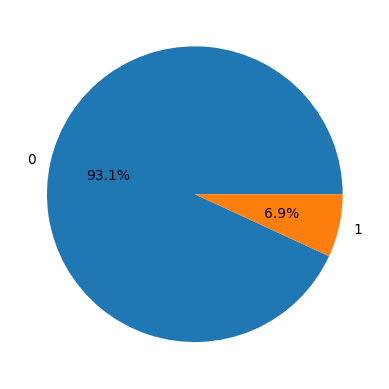

In [69]:
counts = df_grouped['goood'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()


Получаем, что только 7 процентов прям имеет хорошую своевременность.

In [ ]:
df_monthly = (
    df_test
    .groupby(['shop_id', 'item_id', 'date_block_num', ''])['item_cnt_day']
    .sum()
    .reset_index(name='item_cnt_month')
)
df_monthly.head()

,shop_id,item_id,date_block_num,item_cnt_month
0,0,30,1,31.0
1,0,31,1,11.0
2,0,32,0,6.0
3,0,32,1,10.0
4,0,33,0,3.0


Мой план:
1. ПОнять, что хочет от меня заказчик
1. Понять, что из того, что он хочет я вообще могу сделать 
1. Прийти к компромиссу между предыдущими двумя пунктами
1. Нужно сформировать вообще план задачи для дальнейшей работы: это задача классификации / регресси, что для в этой задаче наиболее важно, мне важно прям все точно сделать и тд 
1. Сбор данных
2. Анализ данных по всем критериям 
3. Стараюсь максимально сделать мои данные информативными для дальнейшей работы
4. Пытаюсь выделить самые информативные признаки, добавляю новые
5. Выбираю модели, которые буду использовать, основываясь на самой задаче и характере данных
6. Обучаю, подбираю гиперпараметры, тестирую на тестовой выборке 
7. Выделяю модель, которая на мой взгляд лучше всего подходит для этой задачи и показала хороший результат
8. Прошу модель выдать мне результат итоговый
9. Анализирую, что вообще моя модель мне выдала и пытаюсь понять, как та информация, что я получила, будет полезна моему заказчику
10. Выдаю заказчику ту информаци, которая поможет для его целей